In [106]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [107]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [108]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1

In [109]:
@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [110]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [111]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    # Tells us what intial state for object is
    def initial_state(self) -> Tuple[int, int]:
        return self.start

    # asks if object's currect state is the goal
    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

        raise NotImplementedError("Complete GridProblem.is_goal")

    # checks if state is outside of given bounds by checking if its rows and columsn are less than the given state rows and columns
    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    # Checks if you can move to a given state's co-ord by making sure that that ordinate is not block with a 1 and is indeed 0/free
    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.

        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        for action in MOVES:
            #       a. Compute the neighbour cell.
            dr, dc = MOVES[action]
            neig_row = state[0] + dr
            neig_col = state[1] + dc
            neig_coord = (neig_row, neig_col)
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        if (self.in_bounds(neig_coord)) and (self.is_free(neig_coord)):
            #       d. If valid, add the action name to legal_actions.
            legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions

        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        dr, dc = MOVES[action]
        new_row = state[0] + dr
        new_col = state[1] + dc
        new_coord = (new_row, new_col)
        return new_coord
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

In [112]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [113]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [114]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

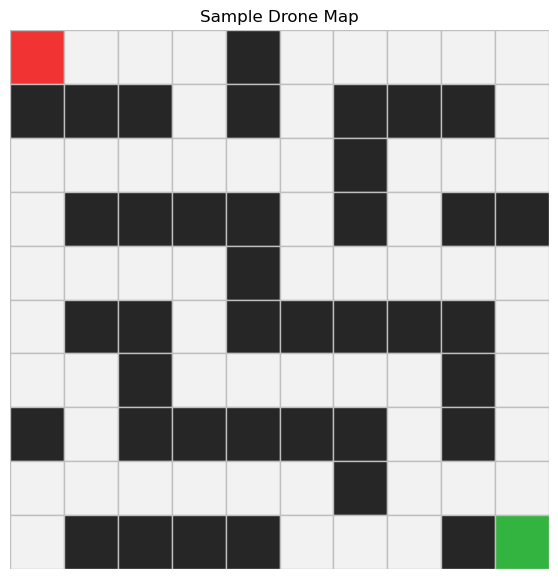

In [115]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [116]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).

        # Pseudocode:
        # s <- node.STATE
        s = node.state
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(s):
            #     s_prime <- problem.RESULT(s, action)
            s_prime = problem.result(s, action)
            #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)
        return
        raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [117]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.

        # Steps:
        # 1. Create the initial node from problem.initial_state().
        node = Node(problem.initial_state())  ###
        nodes_expanded = 0
        max_frontier_size = 0

        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
            )
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([node])
        # 4. Create a reached set and add the initial state.
        reached = {problem.initial_state()}

        # 5. While frontier is not empty:
        while len(frontier) > 0:
            #       a. pop from the LEFT of the deque.
            node = frontier.popleft()
            #       b. increment nodes_expanded.
            nodes_expanded += 1  #
            #       c. expand the node.
            #       d. for each child:
            for child in self.expand(problem, node):
                s = child.state
                #            i. if child is goal, return success.
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=len(frontier),
                    )
                #           ii. if child.state is not in reached:
                if s not in reached:
                    #                  add child.state to reached.
                    reached.add(child.state)
                    #                  append child to frontier.
                    frontier.append(child)
            #       e. update max_frontier_size.
            max_frontier_size = len(frontier)
        # 6. Return failure if no solution is found.
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=len(frontier),
        )
        return
        raise NotImplementedError("Complete BreadthFirstSearch.search")

In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        # TODO 7:
        # Implement DFS graph search using a stack.
        # Steps:
        # 1. Create the initial node.
        node = Node(problem.initial_state())
        nodes_expanded = 0
        max_frontier_size = 1
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1,
            )
        # 3. Use a Python list as the stack frontier.
        frontier = [node]
        # 4. Use a reached set.
        reached_set = {problem.initial_state()}
        while len(frontier) > 0:
            # 5. While frontier is not empty:
            #       a. pop from the end of the list.
            node = frontier.pop()
            #       b. increment nodes_expanded.
            nodes_expanded += 1
            #       c. expand the node.
            #       d. add unreached children to the stack.
            for child in self.expand(problem, node):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached_set),
                    )

                if child.state not in reached_set:
                    reached_set.add(s)
                    frontier.append(child)
            #       e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached_set),
        )
        return
        raise NotImplementedError("Complete DepthFirstSearch.search")

In [119]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 20) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())
        cutoff_occurred: bool

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

        return self._recursive_dls(node=initial_node, problem=problem, limit=limit)

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return node, "success"
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            return None, "cutoff"
        # 3. Otherwise:
        else:
            #    a. increment metrics["nodes_expanded"].
            metrics["nodes_expanded"] += 1
            #       b. set cutoff_occurred = False.
            cutoff_occurred = False
            #       c. for each child in expand(problem, node):
            for child in self.expand(problem, node):
                #             i. skip the child if child.state already appears on the current path.
                if not state_is_on_path(node, child.state):
                    #            ii. update max_stack_size.
                    metrics["max_stack_size"] = max(
                        metrics["max_stack_size"], current_stack_size + 1
                    )
                    #           iii. recursively call _recursive_dls on the child.
                    result, status = self._recursive_dls(
                        problem, child, limit, metrics, current_stack_size + 1
                    )
                    #            iv. if result is "success", return success immediately.
                    if status == "success":
                        return result, "success"

                    #             v. if result is "cutoff", set cutoff_occurred = True.
                    elif status == "cutoff":
                        cutoff_occurred = True
            #       d. after all children:
            if cutoff_occurred:
                return None, "cutoff"
            #             if cutoff_occurred, return (None, "cutoff")
            else:
                return None, "failure"
        #             else return (None, "failure")
        return
        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [120]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        iteration_log = []
        dls = DepthLimitedSearch()
        total_nodes_exp = 0
        max_stack = 0

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)
            # status = result.status
            # Record limit and status
            iteration_log.append((limit, result.status))

            max_stack = max(result.max_frontier_size, max_stack)
            total_nodes_exp += result.nodes_expanded

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_exp,
                    max_frontier_size=max_stack,
                    limit=limit,
                    iterations=iteration_log,
                )

            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=result.solution,
                    nodes_expanded=total_nodes_exp,
                    max_frontier_size=max_stack,
                    limit=limit,
                    iterations=iteration_log,
                )

        return SearchResult("cutoff")

        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        raise NotImplementedError("Complete IterativeDeepeningSearch.search")

In [121]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,4,0,0
1,DFS,failure,NaN,None,None,4,1,4
2,DLS,failure,10.0,None,None,4,4,0
3,IDS,failure,4.0,None,None,10,4,0


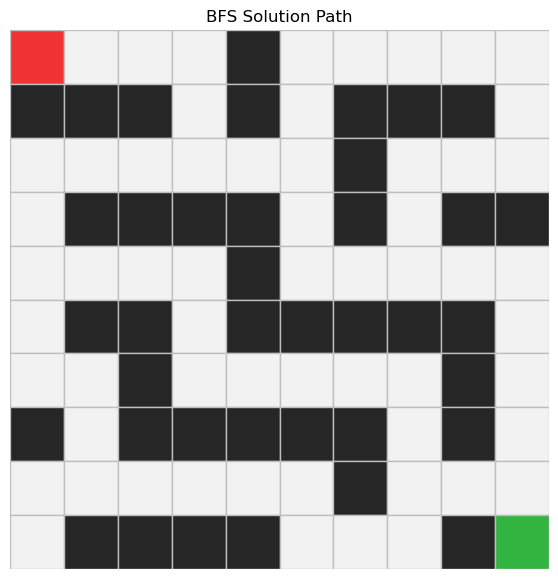

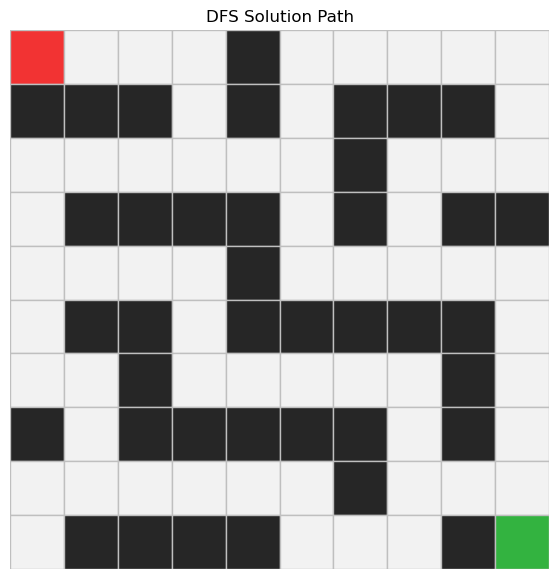

In [122]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [ ]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (14, 0)
custom_goal_1 = (0, 12)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,1,0,0
1,DFS,failure,NaN,None,None,1,1,1
2,DLS,failure,20.0,None,None,1,1,0
3,IDS,failure,1.0,None,None,1,1,0


In [ ]:
# TODO 11:
# Create your first custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
]

custom_start_2 = (14, 14)
custom_goal_2 = (1, 2)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=10),
    ids.search(custom_problem_2, max_depth=50),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,1,0,0
1,DFS,failure,NaN,None,None,1,1,1
2,DLS,failure,20.0,None,None,1,1,0
3,IDS,failure,1.0,None,None,1,1,0


15.1 Problem Formulation
What is a state in this lab?:
The state is the current position of the drone, specifically its grid position
What is an action?:
An action is any movement an agent can make. Here it refers to the up, down, left and right movemetns the drone can make
What does the result function do?:
This gives us the final position of the drone when an action is applied
Why is it useful to separate the problem definition from the search algorithm?
The search space should be able to work with various other problems for reusablitity in other scenarios


15.2 BFS
Why does BFS use a FIFO queue?
BFS expands in order of the first nodes it discovers, "row" by "row". FIFO queues allows it to expand in that order
Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
BFS takes the shortest path as it stops once it finds the first path to the solution and stops its search
What role does the reached set play in BFS?
This allows the algorithmt to know which nodes it has gotten to and which ones it should and should not expand

15.3 DFS
Why does DFS use a stack?:
It expands one node to its end when it discovers it, so a stack would allow it to go through one node and follow that path to its end before moving back to the top and restarting
Is DFS guaranteed to find the shortest path? Explain.:
DFS 
Under what conditions can DFS use less memory than BFS?:
If the goal is within the first path of the DFS it can use less memory than BFS cause the BFS would expand the first node, expand all those paths first before it can check if they're the goal state
Under what conditions can DFS perform badly?:
In urgent situations where nodes lead to several child nodes the DFS can take a long time to find a solution if it gets too deep in its search

15.4 DLS
What happens when the depth limit is too small?:
The solution is most likely not going to be explored and found
What is the meaning of "cutoff"?:
it means the depth of the path was reached and it no longer being explored and the nodes are not being expanded at that point
How is DLS different from ordinary DFS?:
the DLS unline the DFS does not continueb to search a path forever, it cutsoff when its limit for diving deep is reached
Why do we use path-cycle checking in DLS?:
This is to ensure the initial expanded nodes in the root node gets expands

15.5 IDS
Why does IDS repeat DLS with increasing limits?:
It allows the loop to search deeper that DLS to make sure it doesn't lose a good optimal route but it has a limit to ensure it doesn't explore roots with extremely high costs
Why can IDS be complete even though DLS with a small limit is not?:
It is able to alter its limit for each route hence can go a litle deeper to find the shortest route instead of missing them all
Why does IDS use less memory than BFS?:
It does not need to keep track of all its other paths in searching 
What is the cost of repeatedly searching from the root?:
it always has to back-track to that point and recalculate limits 

15.6 Real-World Drone Context
In a real drone application, what might make one route safer or more practical than another?
A safer/practical route would be one which is predictable in nature or does not change to be obstracted, is avaliable to fly over both ways without any issue and is quick to my goal state/destination
Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
I would use IDS as it is more likely to find a short route as it can act "smart". it would be able to find a route without expanding all the possible points near it and only the ones likely to be low in cost which usually is the shortest. I specifically wouldnt use BFS even though it is a close 2nd because if given too many points might end up expanding more than necessary where IDS could expland fewer.
Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
I would chose DLS simply due to the fixed strict depth limit
What limitations does this grid model have compared with real drone navigation?
It does not factor how high a drone can fly in navigation and the grid blocks its path regardless. A real drone's path wont be obstracted by a tree in it's path as it can fly over. it also does not consider diagonal movement and is more limited it its actions unlike a real drone that can move almost any direction. Finally a grid model only allows a limited view of the next nodes to be expaded. real drone navigation (especially from higher views) would be able to see further paths and blocks beyond the ones its on.